## DDIM inversion (initalise with MCPL pretrained)

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch


from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline
from causal_modules.ddim_modules import *
size = 256

image_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

conditioning_image_transforms = transforms.Compose(
            [
                transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.ToTensor(),
                #transforms.Normalize([0.5], [0.5]),
            ]
        )
        

In [2]:
'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"
# before_mcpl_randomhead (random head not work for before transformer)

# work for color editing for pendulum
controlnet_path = "../logs/logs_pendulum_all/2025-11-05T15-44-28-controlnet_textcond_before_mcplgeneration_text_global/controlnet-steps-40000.safetensors"
mcpl_embedding_path = "../logs/logs_pendulum_all/2025-11-05T15-44-28-controlnet_textcond_before_mcplgeneration_text_global/learned_embeds-steps-40000.safetensors"

# controlnet_path = "../logs/logs_pendulum_all/2025-11-05T15-44-11-controlnet_textcond_before_mcpl_headgeneration_text_global/controlnet-steps-40000.safetensors"
# mcpl_embedding_path = "../logs/logs_pendulum_all/2025-11-05T15-44-11-controlnet_textcond_before_mcpl_headgeneration_text_global/learned_embeds-steps-40000.safetensors"

# after_mcpl_randomhead
# controlnet_path = "../logs/logs_pendulum_all/2025-11-05T15-36-02-controlnet_textcond_after_mcpl_headgeneration_text_global_after/controlnet-steps-40000.safetensors"
# mcpl_embedding_path = "../logs/logs_pendulum_all/2025-11-05T15-36-02-controlnet_textcond_after_mcpl_headgeneration_text_global_after/learned_embeds-steps-40000.safetensors"

# controlnet_path = "../logs/logs_pendulum_all/2025-11-05T15-35-55-controlnet_textcond_after_mcpl_randomheadgeneration_text_global_after/controlnet-steps-40000.safetensors"
# mcpl_embedding_path = "../logs/logs_pendulum_all/2025-11-05T15-35-55-controlnet_textcond_after_mcpl_randomheadgeneration_text_global_after/learned_embeds-steps-40000.safetensors"

causalnet_path = None
device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
if causalnet_path is not None:
    print('load pretrained causalnet weights')
    controlnet.controlnet_cond_embedding.load_state_dict(torch.load(causalnet_path,weights_only=True))

A_matrix = torch.tensor([[0, 0, 1,1], [0, 0, 1,1], [0, 0, 0,0], [0, 0, 0,0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.update_mask(A_matrix)
controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding
prompt = 'a image of red @ and orange * and black & and black !'
presudo_words= '@,*,&,!'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", clip_sample=False, set_alpha_to_one=False)
pipe.safety_checker = None
pipe.requires_safety_checker = False
#pipe.load_mcpl_inversion(mcpl_embedding_path)


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
training_mode generation_text_global
Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.
load embedding control


/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76

In [3]:
import os
import random
import numpy as np
from PIL import Image
import torch

def normalize_label_gaussian(label):
    # scale shape: (4, 2) -> [min, range]
    scale = np.array([[2, 42], [104, 44], [7.5, 4.5], [11, 8]])
    norm_label = np.zeros(label.shape)
    for i in range(label.shape[0]):
        norm_label[i] = (label[i] - scale[i][0]) / scale[i][1]
    return norm_label.astype(np.float32)

def normalize_label_minmax(label):
    norm_label = np.zeros(label.shape)
    scale = np.array([[-40,43],[60,147],[3, 12],[2,19]])
    for i in range(label.shape[0]):
        nor_v = (label[i] - scale[i][0]) / (scale[i][1] - scale[i][0])
        # further limit them to (-1,1)
        #norm_label[i] = nor_v*2-1
        norm_label[i] = nor_v
    return norm_label

def dataset_load_path(
    data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/pend_dear_red/train',
    img_path=None,
    device='cuda'
):
    if img_path is None:
        # 从训练集中随机选择一个图像路径
        image_paths = [os.path.join(data_root, f) for f in os.listdir(data_root) if f.endswith('.png')]
        img_path = random.choice(image_paths)
    # image_paths = [os.path.join(data_root, f) for f in os.listdir(data_root) if f.endswith('.png')] 
    # img_path = image_paths[20]
    # 提取文件名中的标签
    filename = os.path.basename(img_path)
    label_values = list(map(float, filename[:-4].split('_')[1:]))  # 跳过开头的 'a_'

    # 归一化标签
    #norm_label = normalize_label_gaussian(np.array(label_values))
    norm_label = normalize_label_minmax(np.array(label_values))
    # 加载图像
    image = Image.open(img_path)

    print(f"Loaded image: {img_path}")
    print(f"Raw label: {label_values}")
    print(f"Normalized label: {norm_label}")

    return image, torch.tensor(norm_label).unsqueeze(0).to(device).float()


#img_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data2/pendulum/train/a_-8_82_3_7.577992553547965.png'
img, label = dataset_load_path(img_path=None)

Loaded image: /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/pend_dear_red/train/a_15.5_75.5_5.464766925529707_11.634880950879264.png
Raw label: [15.5, 75.5, 5.464766925529707, 11.634880950879264]
Normalized label: [0.6686747  0.17816092 0.27386299 0.5667577 ]


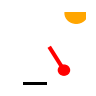

In [23]:
img

100%|██████████| 50/50 [00:03<00:00, 16.42it/s]


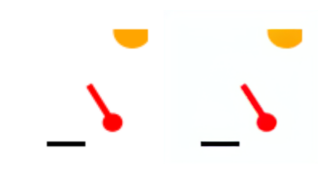

In [24]:

image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

set_guidance_scale  = 1.0
num_steps = 50
s_step = 0
final_im,inverted_latents,_,uncond_embeddings = ddim_editing(pipe, image.unsqueeze(0),label.clone(),prompt,num_steps = num_steps,invert_guidance_scale=1.0,set_guidance_scale  = set_guidance_scale,intervention_indx=None,intervention_values=None,return_PIL=True)
        
to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im[0]]],(1,2),None)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def save_images_grid_box(images_list, grid_size, save_path=None):
    """
    Save a list of lists of images in a grid format with black boxes around each subplot.

    Parameters:
    - images_list: List of lists containing numpy images (4x4).
    - grid_size: tuple (grid_rows, grid_cols) for arranging images in the grid.
    - save_path: file path where the grid image will be saved.
    """
    # Flatten list of lists into a single list
    images = [np.asarray(img) for sublist in images_list for img in sublist]

    # Dimensions of one image
    H, W, C = images[0].shape
    grid_rows, grid_cols = grid_size

    assert grid_rows * grid_cols >= len(images), "Grid size is too small for the number of images"

    # Add border thickness
    border = 1  # pixels for the black box
    grid_image = np.ones(((grid_rows * (H + border) + border),
                          (grid_cols * (W + border) + border),
                          C), dtype=np.uint8) * 0  # black background

    # Place each image inside the grid with borders
    for idx, img in enumerate(images):
        row = idx // grid_cols
        col = idx % grid_cols
        r_start = row * (H + border) + border
        c_start = col * (W + border) + border
        grid_image[r_start:r_start + H, c_start:c_start + W, :] = img

    # Plot and save
    plt.figure(figsize=(grid_cols * 2, grid_rows * 2))
    plt.imshow(grid_image)
    plt.axis('off')
    plt.tight_layout()
    # if save_path is not None:
    #     plt.savefig(save_path, bbox_inches='tight')
    plt.show()


100%|██████████| 50/50 [00:03<00:00, 16.54it/s]


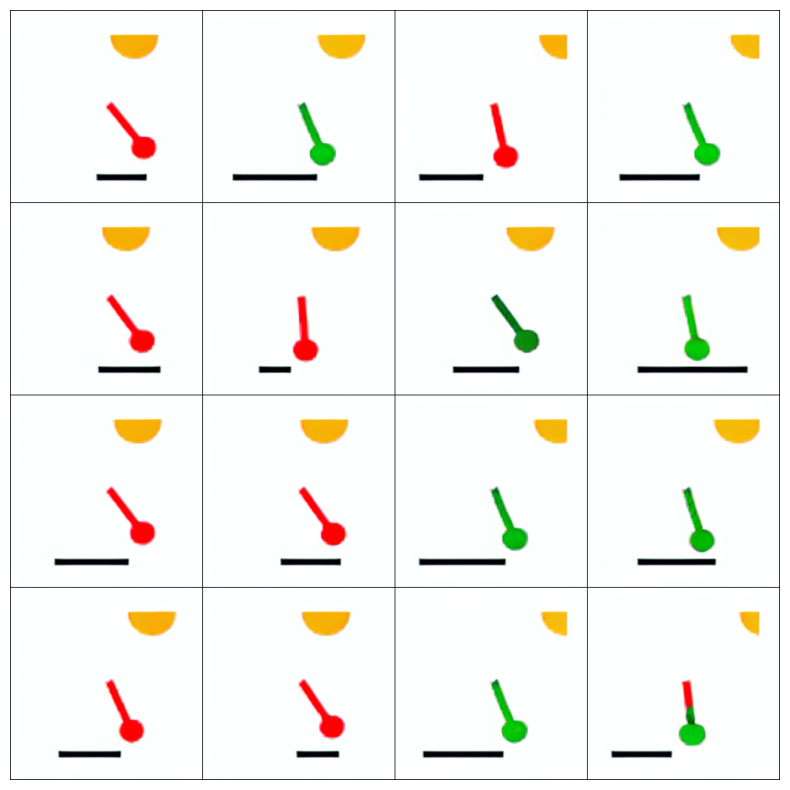

save imgs in ./intervention_variable3.png


In [10]:
from causal_modules.ddim_modules import sample_schedulers
from diffusers.schedulers import UniPCMultistepScheduler
# Do intervention
num_steps = 50
image_lists = []
range_len = 4
inter_value = [np.linspace(0.5, 0.9, num=range_len),
                np.linspace(-0.1, 0.3, num=range_len),
                np.linspace(-0.1, 1.0, num=range_len),
                np.linspace(0, 0.7, num=range_len),
                ]

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

causal_conds = []
#prompt = "red @ and orange * and black & and black !"
prompt = 'green @ and green * and black & and black !'
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1
    for i in range(range_len): 
        s_step = 0
        interved_image,causal_cond = sample_schedulers(
            pipe,
            prompt,
            start_step=s_step,
            start_latents=None,
            #start_latents=inverted_latents[-(s_step + 1)].clone(),
            guidance_scale=10.0,
            num_inference_steps=num_steps,
            num_images_per_prompt=1,
            negative_prompt=None,
            device=device,
            controlnet_image=None,
            intervention_indx=inter_id,
            intervention_values=inter_value[inter_id][i],
            label=label.clone(),
            return_PIL = True,
            disentangle=True,
        )
        causal_conds.append(causal_cond)
        images.append(interved_image[0])
        

    image_lists.append([np.asarray(img) for img in images])
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid_box(image_lists,(4,range_len),save_path)
print('save imgs in {}'.format(save_path))

#[ 0.35714287  0.70454544 -0.9758932   0.52332103]

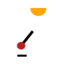

In [ ]:

# Do intervention
image_lists = []
range_len = 4
inter_value = [np.linspace(-1, 1.0, num=range_len),
                np.linspace(-0.9, 1.0, num=range_len),
                np.linspace(-0.8, 0.65, num=range_len),
                np.linspace(-0.9, -0.2, num=range_len),
                ] 
causal_conds = []
for inter_id in range(0,1,1):
    images = []
    #inter_value  = -1
    for i in range(range_len): 
        s_step = 0
        interved_image,causal_cond = sample(
            pipe,
            prompt,
            start_step=s_step,
            #start_latents=None,
            start_latents=inverted_latents[-(s_step + 1)].clone(),
            guidance_scale=3.5,
            num_inference_steps=num_steps,
            num_images_per_prompt=1,
            negative_prompt=None,
            device=device,
            controlnet_image=None,
            intervention_indx=inter_id,
            intervention_values=inter_value[inter_id][i],
            label=label.clone(),
            return_PIL = True,
            disentangle=False,
            uncond_embeddings=uncond_embeddings,
        )
        causal_conds.append(causal_cond)
        images.append(interved_image[0])
        

    image_lists.append([np.asarray(img) for img in images])
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid_box(image_lists,(4,range_len),save_path)
print('save imgs in {}'.format(save_path))

#[ 0.35714287  0.70454544 -0.9758932   0.52332103]

In [39]:
import os
save_path = '../outputs/datasets/pendulum/DDIM/{}'.format(1)
os.makedirs(save_path, exist_ok=True)

# Resize and save each image
for i, img in enumerate(tqdm(arr, desc="Resizing and saving")):
    # Convert to PIL image
    pil_img = Image.fromarray(img)
    # pil_img.save(os.path.join(save_path, f"{i}.png"))
    # Resize to 64×64
    resized_img = pil_img.resize((64, 64), Image.BICUBIC)
    # Save as PNG
    resized_img.save(os.path.join(save_path, f"{i}.png"))


Resizing and saving: 100%|██████████| 32/32 [00:00<00:00, 193.30it/s]


# P2P

50it [00:05,  9.99it/s]
50it [00:05,  9.99it/s]
50it [00:05,  9.96it/s]
50it [00:05,  9.96it/s]
50it [00:05,  9.96it/s]
50it [00:05,  9.96it/s]
50it [00:05,  9.96it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.95it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.95it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.95it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.93it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.93it/s]
50it [00:05,  9.93it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.94it/s]
50it [00:05,  9.91it/s]


save imgs in ./intervention_variable3.png


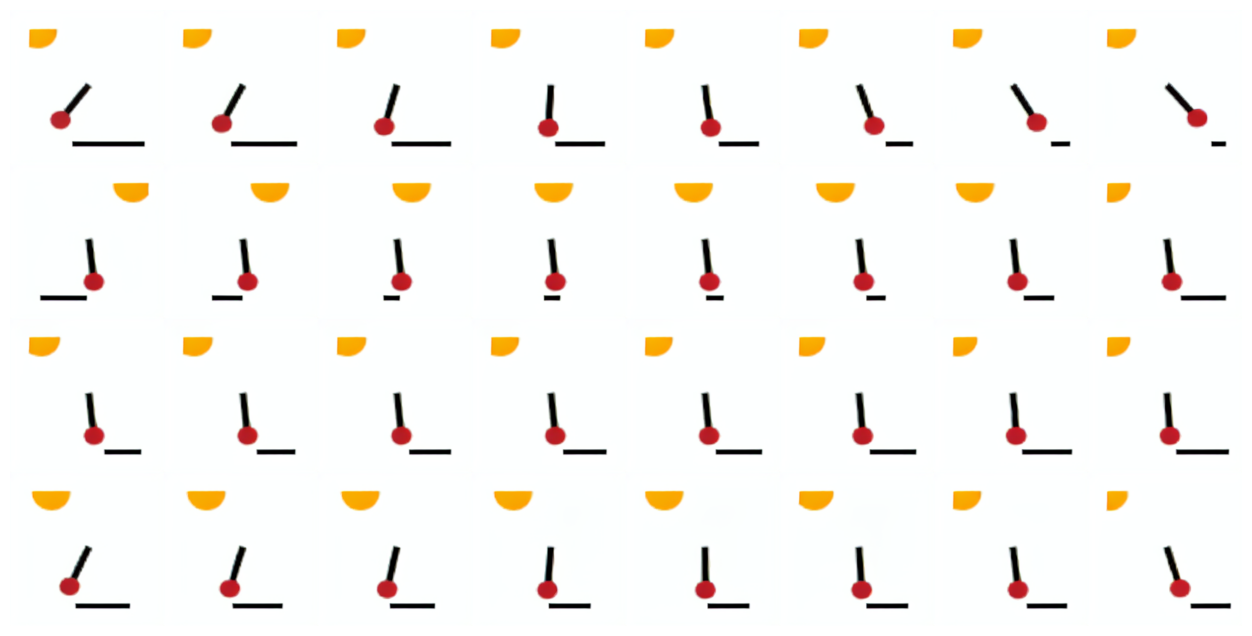

In [16]:

# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 3.0
num_steps = 50      
s_step = 0
invert_guidance_scale=1.0
# False use the normal DDIM 
blend_word = True
# start_blend=0.2, th=(.3, .3)

# Do intervention
image_lists = []
range_len = 8
inter_value = [np.linspace(-1, 1.0, num=range_len),
                np.linspace(-1, 1.0, num=range_len),
                np.linspace(-0.5, 0.8, num=range_len),
                np.linspace(-1, 0.875, num=range_len),
                ] 
causal_conds = []


for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1
    for i in range(range_len): 
        blend_params = {'start_blend':0.0,'th':(0.3,0.3)}
        cross_replace_steps,self_replace_steps = 0.0,0.0

        interved_image,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0),
                                                            label.clone(),prompt,presudo_list,
                                                            num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,
                                                            set_guidance_scale  = set_guidance_scale,intervention_indx=inter_id,
                                                            intervention_values=inter_value[inter_id][i],return_PIL=True,
                                                            blend_word=blend_word,blend_params=blend_params,
                                                            disentangle=False,
                                                            cross_replace_steps=cross_replace_steps,self_replace_steps=self_replace_steps,)
        images.append(interved_image[0])
    image_lists.append([np.asarray(img) for img in images])
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid(image_lists,(4,range_len),save_path)
print('save imgs in {}'.format(save_path))

In [13]:
def denormalize_label_gaussian(norm_label):
    # same scale used during normalization
    scale = np.array([[2, 42], [104, 44], [7.5, 4.5], [11, 8]])
    original_label = np.zeros(norm_label.shape)
    for i in range(norm_label.shape[0]):
        original_label[i] = norm_label[i] * scale[i][1] + scale[i][0]
    return original_label.astype(np.float32)

In [ ]:
import math
scale = np.array([[2, 42], [104, 44], [7.5, 4.5], [11, 8]])
def projection(theta, phi, x, y, base = -0.5):
    b = y-x*math.tan(phi)
    shade = (base - b)/math.tan(phi)
    return shade

denorm_array = denormalize_label_gaussian(causal_conds[2].squeeze().cpu().numpy())
i = denorm_array[0]
j = denorm_array[1]
theta = i*math.pi/200.0
phi = j*math.pi/200.0
x = 10 + 8*math.sin(theta)
y = 10.5 - 8*math.cos(theta)

#calculate the mid index of 
ball_x = 10+9.5*math.sin(theta)
ball_y = 10.5-9.5*math. cos(theta)
mid = (projection(theta, phi, 10.0, 10.5)+projection(theta, phi, ball_x, ball_y))/2
shade = max(3,abs(projection(theta, phi, 10.0, 10.5)-projection(theta, phi, ball_x, ball_y)))

print('GT:',shade,mid)
print('prediction',denorm_array[2],denorm_array[3])


GT: 3.2761570548614554 15.102730142108523
prediction 3.2789514 15.129621


# Generation

In [12]:
'''Load pipeline'''
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch

from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler
from causal_modules.ddim_modules import *

'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"


#controlnet_path = "../logs/logs_pendulum_all/2025-05-12T12-27-57-controlnet_textcond_contrastgeneration_text_global_after/controlnet-steps-100000.safetensors"
#mcpl_embedding_path = "../logs/logs_pendulum_all/2025-05-12T12-27-57-controlnet_textcond_contrastgeneration_text_global_after/learned_embeds-steps-100000.safetensors"
controlnet_path = "../logs/logs_pendulum_all/2025-05-30T14-29-11-controlnet_textcond_contrast_data2generation_text_global_after/controlnet-steps-20000.safetensors"
mcpl_embedding_path = "../logs/logs_pendulum_all/2025-05-30T14-29-11-controlnet_textcond_contrast_data2generation_text_global_after/learned_embeds-steps-20000.safetensors"
#controlnet_path = "../logs/logs_pendulum_all/2025-05-30T14-33-58-controlnet_textcond_contrast_dataDEARgeneration_text_global_after/controlnet-steps-20000.safetensors"
#mcpl_embedding_path = "../logs/logs_pendulum_all/2025-05-30T14-33-58-controlnet_textcond_contrast_dataDEARgeneration_text_global_after/learned_embeds-steps-20000.safetensors"



causalnet_path = None
device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
if causalnet_path is not None:
    print('load pretrained causalnet weights')
    controlnet.controlnet_cond_embedding.load_state_dict(torch.load(causalnet_path,weights_only=True))

A_matrix = torch.tensor([[0, 0, 1,1], [0, 0, 1,1], [0, 0, 0,0], [0, 0, 0,0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.update_mask(A_matrix)
controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding
prompt = "a image of @ and * and & and !"
#prompt = 'a photo of a @ and * and & and !'
#prompt = '@ * & !'
presudo_words= '@,*,&,!'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", clip_sample=False, set_alpha_to_one=False)
# pipe.scheduler = UniPCMultistepScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.safety_checker = None
pipe.requires_safety_checker = False
#pipe.load_mcpl_inversion(mcpl_embedding_path)


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
training_mode generation_text_global_after
Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.
load embedding control


/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76

In [13]:
# do intervention (beard, manual seed 10, start from -1, gs lower , more obvious the OOD feature)
# [0.4, 0.6, 0.5, 0.5]， inter_id=3, 0~0.5
inter_id=3
range_len=4
inter_value = torch.from_numpy(np.linspace(0, 1, num=range_len))
# Do intervention
image_lists = []


noise = torch.randn(1, 4, 32, 32,generator=torch.manual_seed(2)).to(device)
fixed_noise =noise*pipe.scheduler.init_noise_sigma

images = []
#inter_value  = -1   
s_step = 0

for j in range(0,range_len,1):
    interved_image = pipe(
        prompt, 
        num_inference_steps=50, 
        generator=None, 
        image=noise,
        height=256,
        width=256,
        guidance_scale=1.0,
        training=False,
        latents = fixed_noise,
        intervention_indx=inter_id,
        intervention_values=inter_value[j],
        label = torch.tensor([0.4, 0.6, 0.5, 0.5]).unsqueeze(0)
    ).images[0]
    image_lists.append(np.asarray(interved_image))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,range_len),save_path)


  0%|          | 0/50 [00:00<?, ?it/s]

ValueError: not enough values to unpack (expected 3, got 2)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

save imgs in ./intervention_variable3.png


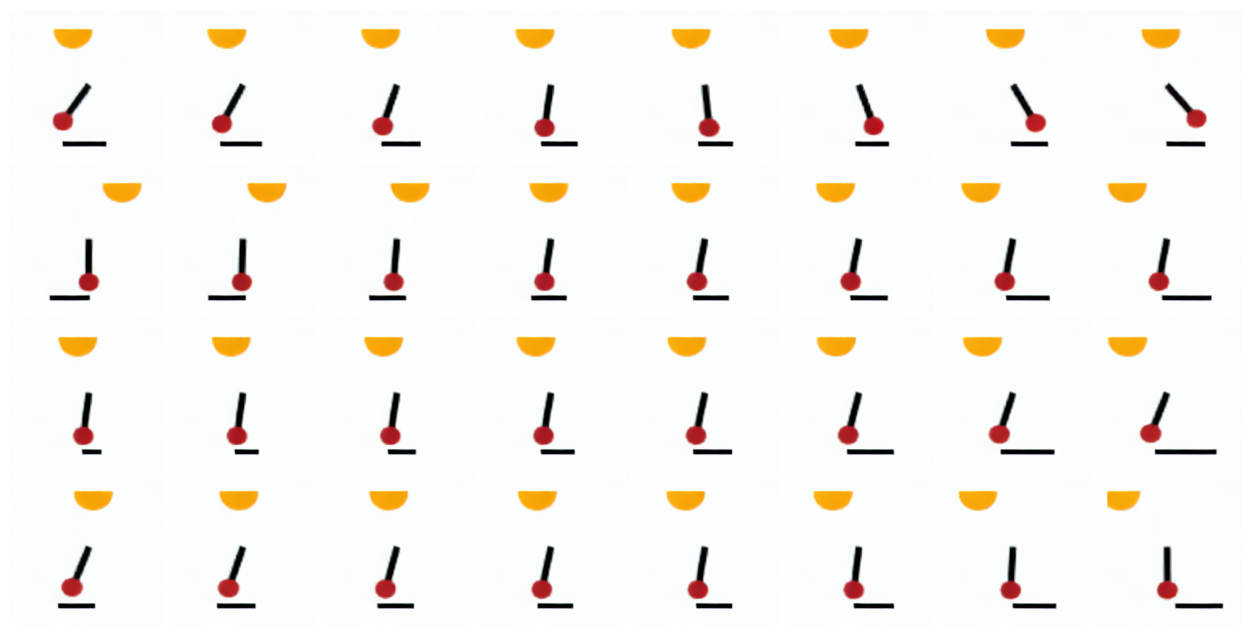

In [16]:

# Do intervention
image_lists = []
range_len = 8
inter_value = [np.linspace(0, 1.0, num=range_len),
                np.linspace(0, 1.0, num=range_len),
                np.linspace(0, 1.0, num=range_len),
                np.linspace(0, 1.0, num=range_len),
                ] 
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1
    for i in range(range_len): 
        s_step = 0
        interved_image = pipe(
            prompt, 
            num_inference_steps=50, 
            generator=None, 
            image=noise,
            height=256,
            width=256,
            guidance_scale=1.0,
            training=False,
            latents = fixed_noise,
            intervention_indx=inter_id,
            intervention_values=inter_value[inter_id][i],
            label = torch.tensor([0.4, 0.6, 0.5, 0.5]).unsqueeze(0)
        ).images[0]
        
        images.append(np.asarray(interved_image))
        

    image_lists.append([np.asarray(img) for img in images])
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid(image_lists,(4,range_len),save_path)
print('save imgs in {}'.format(save_path))